# NDVI temporal signature (time series) analysis by cluster (second classification) in Bajo de los Saladillos (2000-2022)

## Import libraries

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
from google.colab import files

## Data processing

In [2]:
# Import data from GH repo
!wget https://raw.githubusercontent.com/francobarrionuevoenv21/ClusteringPaddyFields_Fires_SanJavier/refs/heads/main/Data_results/03_2_2dokmeans_ndvi_pivot.csv

--2025-08-10 22:57:55--  https://raw.githubusercontent.com/francobarrionuevoenv21/ClusteringPaddyFields_Fires_SanJavier/refs/heads/main/Data_results/03_2_2dokmeans_ndvi_pivot.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13327341 (13M) [text/plain]
Saving to: ‘03_2_2dokmeans_ndvi_pivot.csv’

03_2_2dokmeans_ndvi 100%[===================>]  12.71M  --.-KB/s    in 0.1s    

2025-08-10 22:57:55 (97.3 MB/s) - ‘03_2_2dokmeans_ndvi_pivot.csv’ saved [13327341/13327341]



In [3]:
# Load the csv file
dfLoaded = pd.read_csv('/content/03_2_2dokmeans_ndvi_pivot.csv')

/tmp/ipython-input-3373347235.py:2: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,2

In [8]:
# Quick visualization of the dataset
dfLoaded.head()

,cluster,longitude,latitude,NDVI1,NDVI1.1,NDVI1.2,NDVI1.3,NDVI1.4,NDVI1.5,NDVI1.6,...,NDVI1.516,NDVI1.517,NDVI1.518,NDVI1.519,NDVI1.520,NDVI1.521,NDVI1.522,NDVI1.523,NDVI1.524,NDVI1.525
0,NaN,NaN,NaN,2000-02-18,2000-03-05,2000-03-21,2000-04-06,2000-04-22,2000-05-08,2000-05-24,...,2022-07-28,2022-08-13,2022-08-29,2022-09-14,2022-09-30,2022-10-16,2022-11-01,2022-11-17,2022-12-03,2022-12-19
1,1.0,-60.181510,-30.712277,7432.0,7817.0,4754.0,7966.0,8044.0,8186.0,7961.0,...,3173.0,3921.0,3976.0,4675.0,3568.0,4080.0,3551.0,4582.0,7065.0,6681.0
2,1.0,-60.181510,-30.707785,7331.0,7474.0,5191.0,7900.0,7930.0,8166.0,7916.0,...,3025.0,2735.0,3197.0,3024.0,2876.0,2874.0,2945.0,3700.0,8191.0,7955.0
3,1.0,-60.179264,-30.712277,7219.0,7756.0,4954.0,7966.0,8115.0,8264.0,7880.0,...,4112.0,3921.0,3672.0,4385.0,4202.0,3670.0,4277.0,4507.0,5814.0,6880.0
4,1.0,-60.179264,-30.710031,6809.0,7420.0,2575.0,8107.0,8158.0,8166.0,8415.0,...,3595.0,3264.0,3370.0,3883.0,2833.0,3670.0,3364.0,5612.0,8077.0,6880.0


In [6]:
# Extract NDVI data and dates series
dfNDVIsamples = dfLoaded.copy()
pdsFechas = dfNDVIsamples.iloc[0, 3:]

## NDVI temporal signature visualizacion by cluster

In [9]:
Ncluster = 1 # SELECT THE CLUSTER FROM 1 TO 40
matrixClusterNDVI = dfNDVIsamples[dfNDVIsamples['cluster']==Ncluster].iloc[:, 3:].astype('float').to_numpy()/10000

/tmp/ipython-input-1618998704.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  axs.plot(pdsFechas, mean_1, 'b-', label=f'Cluster N{Ncluster}', color='limegreen')


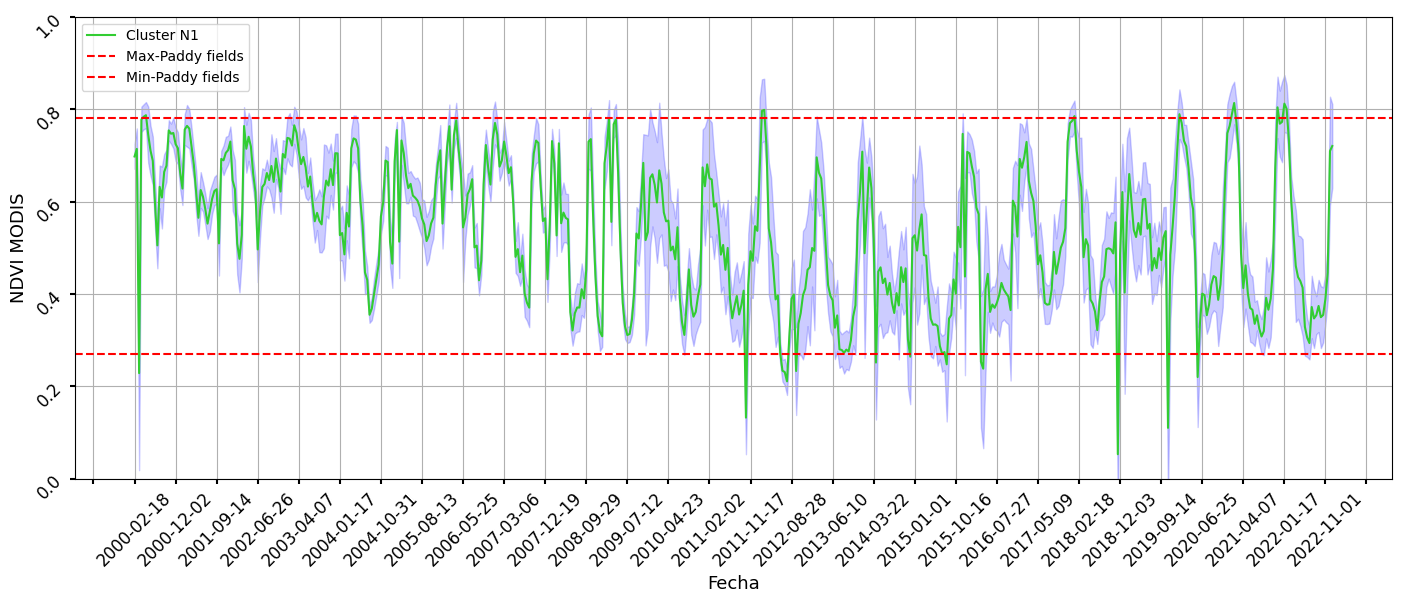

In [10]:
fig, axs = plt.subplots(figsize=(17, 6))

mean_1 = np.mean(matrixClusterNDVI, axis=0)
std_1 = np.std(matrixClusterNDVI, axis=0)

axs.plot(pdsFechas, mean_1, 'b-', label=f'Cluster N{Ncluster}', color='limegreen')
axs.fill_between(pdsFechas, mean_1 - std_1, mean_1 + std_1, color='b', alpha=0.2)

axs.set_ylabel('NDVI MODIS', fontsize=13)
axs.set_xlabel('Fecha', fontsize=13)

axs.axhline(y=0.78, label='Max-Paddy fields',color='red', linestyle='--')
axs.axhline(y=0.27, label='Min-Paddy fields',color='red', linestyle='--')

axs.xaxis.set_major_locator(plt.MultipleLocator(base=18))
axs.tick_params(axis='both', labelsize=12, rotation=45, width=1.5)

axs.grid(True)
axs.set_ylim(0,1)
axs.legend(loc='best')
plt.show()

# Summary delta NDVI (2000-2022)

In [11]:
# Clusters identified as paddy fields selection
listClustSelecc = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 15, 17, 18, 20, 21, 22, 23, 24, 26, 27, 28, 30, 31, 32, 33, 34, 35, 37, 39, 40]

In [12]:
# Function to compute monthly mean NDVI value
def meanValMonth(pdsFechas, meanNDVIxClust, YY, MM):
  dfFechasS_Filt = pd.DataFrame()
  dfFechasS_Filt['Fecha'] = pdsFechas
  dfFechasS_Filt['Fecha'] = pd.to_datetime(dfFechasS_Filt['Fecha'], format='%Y-%m-%d')
  dfFechasS_Filt = dfFechasS_Filt.reset_index()
  dfFechasFilt = dfFechasS_Filt[(dfFechasS_Filt['Fecha'] >= f'{YY}-{MM}-01') & (dfFechasS_Filt['Fecha'] <= f'{YY}-{MM}-31')]
  return (meanNDVIxClust[list(dfFechasFilt.index)]).mean()

1
2
3


/tmp/ipython-input-1763784576.py:7: RuntimeWarning: Mean of empty slice.
  return (meanNDVIxClust[list(dfFechasFilt.index)]).mean()
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-1763784576.py:7: RuntimeWarning: Mean of empty slice.
  return (meanNDVIxClust[list(dfFechasFilt.index)]).mean()
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-1763784576.py:7: RuntimeWarning: Mean of empty slice.
  return (meanNDVIxClust[list(dfFechasFilt.index)]).mean()
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


4
5


/tmp/ipython-input-1763784576.py:7: RuntimeWarning: Mean of empty slice.
  return (meanNDVIxClust[list(dfFechasFilt.index)]).mean()
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-1763784576.py:7: RuntimeWarning: Mean of empty slice.
  return (meanNDVIxClust[list(dfFechasFilt.index)]).mean()
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


6
7
8


...

/tmp/ipython-input-1763784576.py:7: RuntimeWarning: Mean of empty slice.
  return (meanNDVIxClust[list(dfFechasFilt.index)]).mean()
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-1763784576.py:7: RuntimeWarning: Mean of empty slice.
  return (meanNDVIxClust[list(dfFechasFilt.index)]).mean()
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-1763784576.py:7: RuntimeWarning: Mean of empty slice.
  return (meanNDVIxClust[list(dfFechasFilt.index)]).mean()
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


35
37
39


/tmp/ipython-input-1763784576.py:7: RuntimeWarning: Mean of empty slice.
  return (meanNDVIxClust[list(dfFechasFilt.index)]).mean()
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-1763784576.py:7: RuntimeWarning: Mean of empty slice.
  return (meanNDVIxClust[list(dfFechasFilt.index)]).mean()
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


40


/tmp/ipython-input-1763784576.py:7: RuntimeWarning: Mean of empty slice.
  return (meanNDVIxClust[list(dfFechasFilt.index)]).mean()
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
# Creates a dataframe with yearly delta NDVI (Jan-Aug) for each cluster for the period 2000-2022
dfdeltaNDVIxClus = pd.DataFrame()
dfdeltaNDVIxClus['Año'] = list(range(2000, 2023))

for Ncluster in listClustSelecc:

  print(Ncluster)
  matrixClusterNDVI = dfNDVIsamples[dfNDVIsamples['cluster']==Ncluster].iloc[:, 3:].astype('float').to_numpy()
  meanNDVIxClust = np.mean(matrixClusterNDVI, axis=0)

  dfdeltaNDVIxClus[f'Cluster N{Ncluster}'] = [ (meanValMonth(pdsFechas, meanNDVIxClust, y,1)-meanValMonth(pdsFechas, meanNDVIxClust, y,8)) for y in range(2000, 2023)]

## Table exporting

In [19]:
# determining the name of the file
file_name = 'DeltaNDVIxAnio.xlsx'

# saving the excel
dfdeltaNDVIxClus.to_excel(file_name, index=False)

# download
files.download('DeltaNDVIxAnio.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>